In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [ ]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [ ]:
data.describe(include="all")

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


In [ ]:
# Univariate Analysis

target_col = 'stroke'
id_col = 'id'

categorical_cols_all = data.select_dtypes(include=['str']).columns.tolist()
numerical_cols_all = data.select_dtypes(exclude=['str']).columns.tolist()

In [ ]:
categorical_cols_all

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

In [ ]:

numerical_cols_all

['id',
 'age',
 'hypertension',
 'heart_disease',
 'avg_glucose_level',
 'bmi',
 'stroke']

In [ ]:
numerical_cols_all.remove(id_col)
numerical_cols_all.remove(target_col)

In [ ]:
numerical_cols_all

['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

In [ ]:
categorical_cols_all

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

In [ ]:
numeric_col = []

for col in numerical_cols_all:
    if data[col].nunique() < 10:
        categorical_cols_all.append(col)
    else:
        numeric_col.append(col)        

In [ ]:
numeric_col

['age', 'avg_glucose_level', 'bmi']

In [ ]:
categorical_cols_all

['gender',
 'ever_married',
 'work_type',
 'Residence_type',
 'smoking_status',
 'hypertension',
 'heart_disease']

C:\Users\Surya\AppData\Local\Temp\ipykernel_10868\3646672585.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette='Set2')
C:\Users\Surya\AppData\Local\Temp\ipykernel_10868\3646672585.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette='Set2')
C:\Users\Surya\AppData\Local\Temp\ipykernel_10868\3646672585.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette='Set2')
C:\Users\Surya\AppData\Local\Temp\ipykernel_10868\3646672585.py:6: FutureWarning: 

Passing `palette

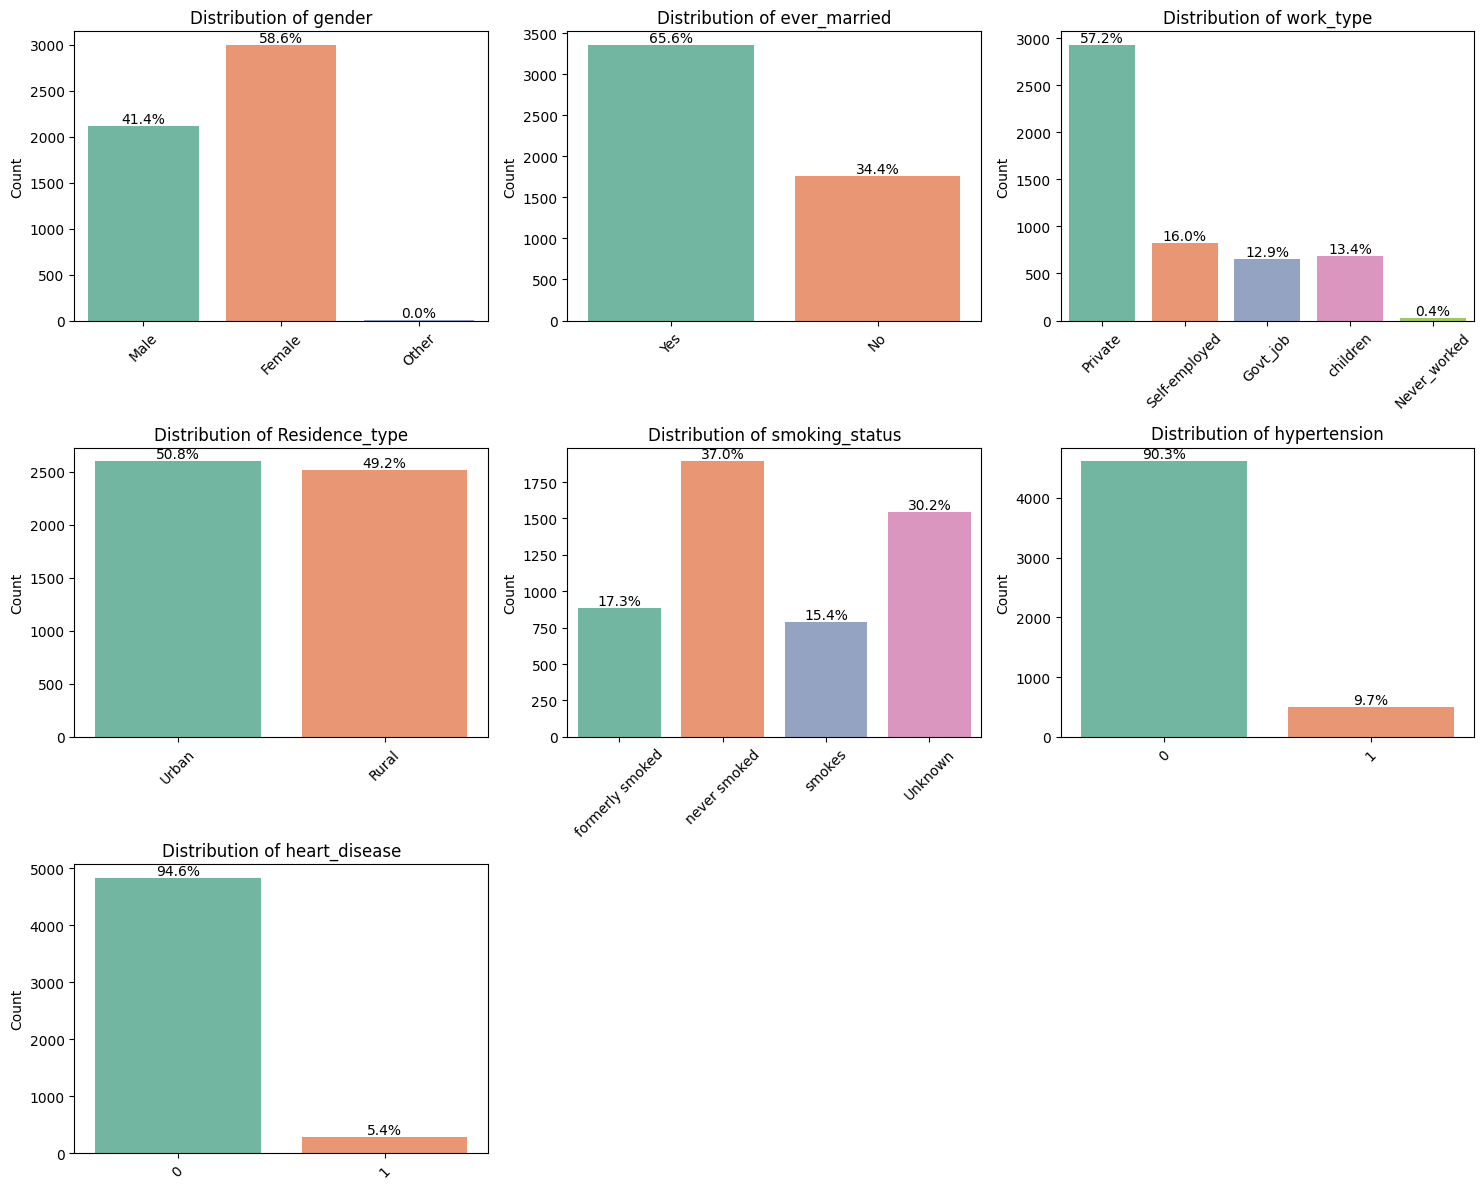

In [ ]:
plt.figure(figsize=(15, 12))

for i, col in enumerate(categorical_cols_all):
    ax = plt.subplot(3, 3, i + 1)

    sns.countplot(data=data, x=col, palette='Set2')

    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel('')
    plt.ylabel('Count')
    plt.xticks(rotation=45)


    total = len(data)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom')


plt.tight_layout()
plt.show()

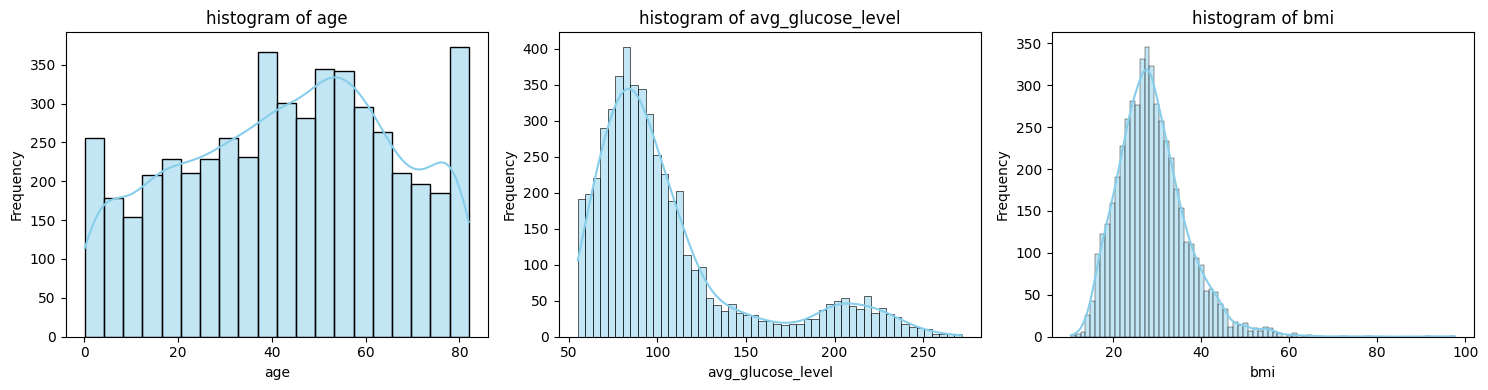

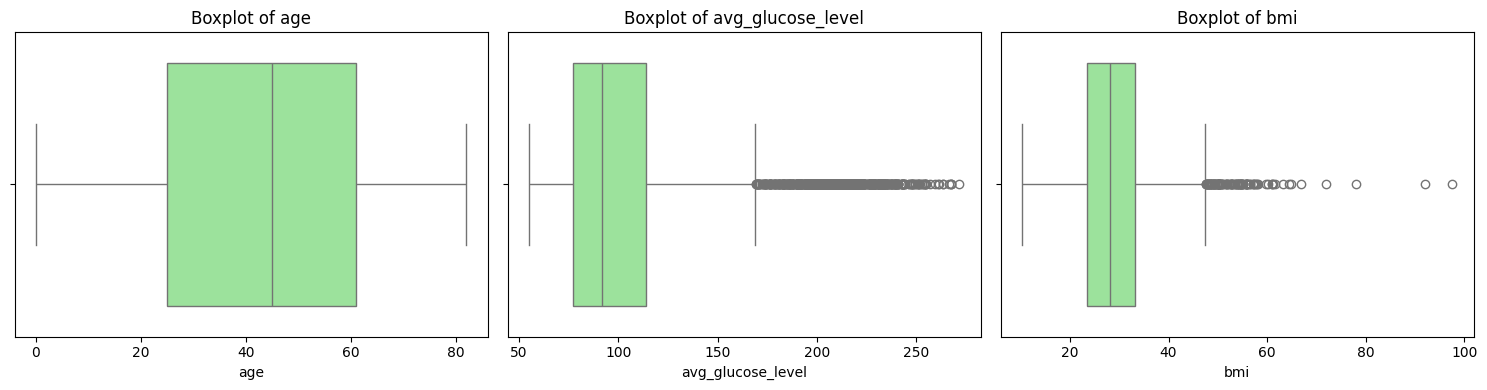

In [ ]:
plt.figure(figsize=(15, 4))

for i, col in enumerate(numeric_col):
    plt.subplot(1, 3, i + 1)
    sns.histplot(data=data, x=col, kde=True, color='skyblue')
    plt.title(f'histogram of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#Univarient analysis to check the outliers using boxplot

plt.figure(figsize=(15, 4))
for i, col in enumerate(numeric_col):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=data, x=col, color='lightgreen')
    plt.title(f"Boxplot of {col}", fontsize=12)
    plt.xlabel(col)
    
plt.tight_layout()   
plt.show() 


In [ ]:
stroke_counts = data[target_col].value_counts()
stroke_counts

stroke
0    4861
1     249
Name: count, dtype: int64

C:\Users\Surya\AppData\Local\Temp\ipykernel_10868\1519935533.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x=target_col, palette='viridis')


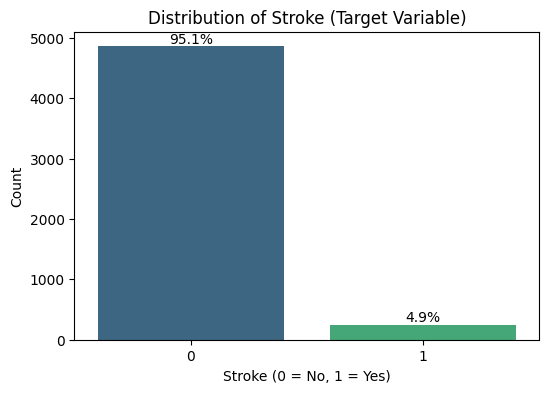

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x=target_col, palette='viridis')
plt.title('Distribution of Stroke (Target Variable)')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Count')

total = len(data)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

Birvarient Analysis

In [ ]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(categorical_cols_all):
    ax = plt.subplot(3, 3, i+1)
    sns.countplot(data=data, x=col, hue=target_col, palette="Set1")
    plt.title(f"{col} vs stroke", fontsize=12)
    plt.xlabel('')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
